In [1]:
import os
import random
import h5py

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary
from sklearn.metrics import r2_score
import plotly.express as px


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import torchvision.transforms.functional as TF

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

generator = torch.Generator().manual_seed(SEED)

# Set the device to use for training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Data

In [2]:
folder_path = "models/"

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if not os.path.exists(os.path.join(folder_path, "checkpoints")):
    os.makedirs(os.path.join(folder_path, "checkpoints"))

- Reading files

In [3]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": types_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

In [4]:
path = "../src/data/processed/disaster.h5"
df_disaster = read_hdf5_to_dataframe_with_index(path)

path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

# load csv iso3 embeddings
iso3_embeddings = pd.read_csv("../src/data/processed/embeddings_mapped.csv", index_col=0)

# combine the two dataframes
df = pd.concat([df_disaster, df_idu], ignore_index=True)

del df_disaster
del df_idu

In [5]:
len(df)

16896

In [6]:
iso3_embeddings.head()

,emb_0,emb_1,emb_2,emb_3
iso3_mapped,,,,
AND,-2.155526,-0.099045,1.090775,0.091681
ARE,-2.354902,-0.086402,1.196469,0.499288
AFG,2.381075,-0.013857,-0.791427,0.159821
ATG,-0.600651,-0.696483,-1.296734,1.598701
ALB,0.138654,-0.234058,-0.686938,-0.162994


In [7]:
def plot_iso3_distribution(df):
    iso3_counts = df["iso3"].value_counts().reset_index()
    iso3_counts.columns = ["iso3", "count"]
    iso3_counts["log_count"] = np.log1p(iso3_counts["count"])
    top_10 = iso3_counts.nlargest(10, "count").sort_values("count")

    # Figure 1: global choropleth
    fig_map = px.choropleth(
        iso3_counts,
        locations="iso3",
        color="log_count",
        hover_name="iso3",
        hover_data={"count": ":.0f", "log_count": False},
        color_continuous_scale="Magma",
        title="<b>Climate related disaster concentration by country</b><br><sub>Global map</sub>",
    )
    fig_map.update_geos(
        projection_type="equirectangular",
        lataxis_range=[-58, 90],
        showframe=False,
        showcoastlines=False,
        showland=True,
        landcolor="rgb(245,245,245)",
    )
    fig_map.update_layout(
        template="simple_white",
        title=dict(x=0.5, xanchor="center"),
        height=620,
        width=1100,
        margin=dict(l=20, r=20, t=80, b=10),
        font=dict(size=12),
        coloraxis_colorbar=dict(
            title="Log events",
            thickness=12,
            len=0.7,
        ),
    )
    fig_map.show()

    # Figure 2: top countries bar chart
    fig_bar = px.bar(
        top_10,
        y="iso3",
        x="count",
        orientation="h",
        color="count",
        color_continuous_scale="Magma",
        title="<b>Climate related disasters by country</b>",
        labels={"iso3": "Country", "count": "Events"},
    )
    fig_bar.update_traces(
        cliponaxis=False,
        marker_line_color="rgba(0,0,0,0.08)",
        marker_line_width=1,
    )
    fig_bar.update_layout(
        template="simple_white",
        title=dict(x=0.5, xanchor="center"),
        height=520,
        width=760,
        margin=dict(l=20, r=30, t=80, b=20),
        font=dict(size=12),
        showlegend=False,
        xaxis=dict(showgrid=True, gridcolor="rgba(0,0,0,0.08)", title="Events"),
        yaxis=dict(title="", automargin=True),
    )
    fig_bar.show()

    print(f"Top 10 countries account for {top_10['count'].sum() / iso3_counts['count'].sum() * 100:.1f}% of events")
    print(", ".join(top_10["iso3"].tolist()))


plot_iso3_distribution(df)

Top 10 countries account for 54.5% of events
LKA, MYS, PHL, USA, BDI, IND, IDN, BRA, SOM, PER


# Simple baseline


=== EMBEDDING MODEL ===
{'R2': 0.29196256399154663, 'MAE': 1.646234154701233, 'RMSE': np.float64(2.115392508191943)}

=== FULL MODEL ===
{'R2': 0.41819411516189575, 'MAE': 1.4690190553665161, 'RMSE': np.float64(1.9175730994464282)}

=== TOP FEATURES ===
   feature  importance_mean  importance_std              display_name
26    ve_2         0.136726        0.011870             VIIRS end min
3    emb_3         0.130887        0.008837  Country embedding: emb_3
16    vs_0         0.093676        0.005529          VIIRS start mean
2    emb_2         0.093651        0.008714  Country embedding: emb_2
0    emb_0         0.073012        0.005601  Country embedding: emb_0
31    ve_7         0.068820        0.004788             VIIRS end ptp
22    vs_6         0.056698        0.005523          VIIRS start 75th
18    vs_2         0.049862        0.004899           VIIRS start min
17    vs_1         0.049495        0.003289           VIIRS start std
1    emb_1         0.049127        0.005264  

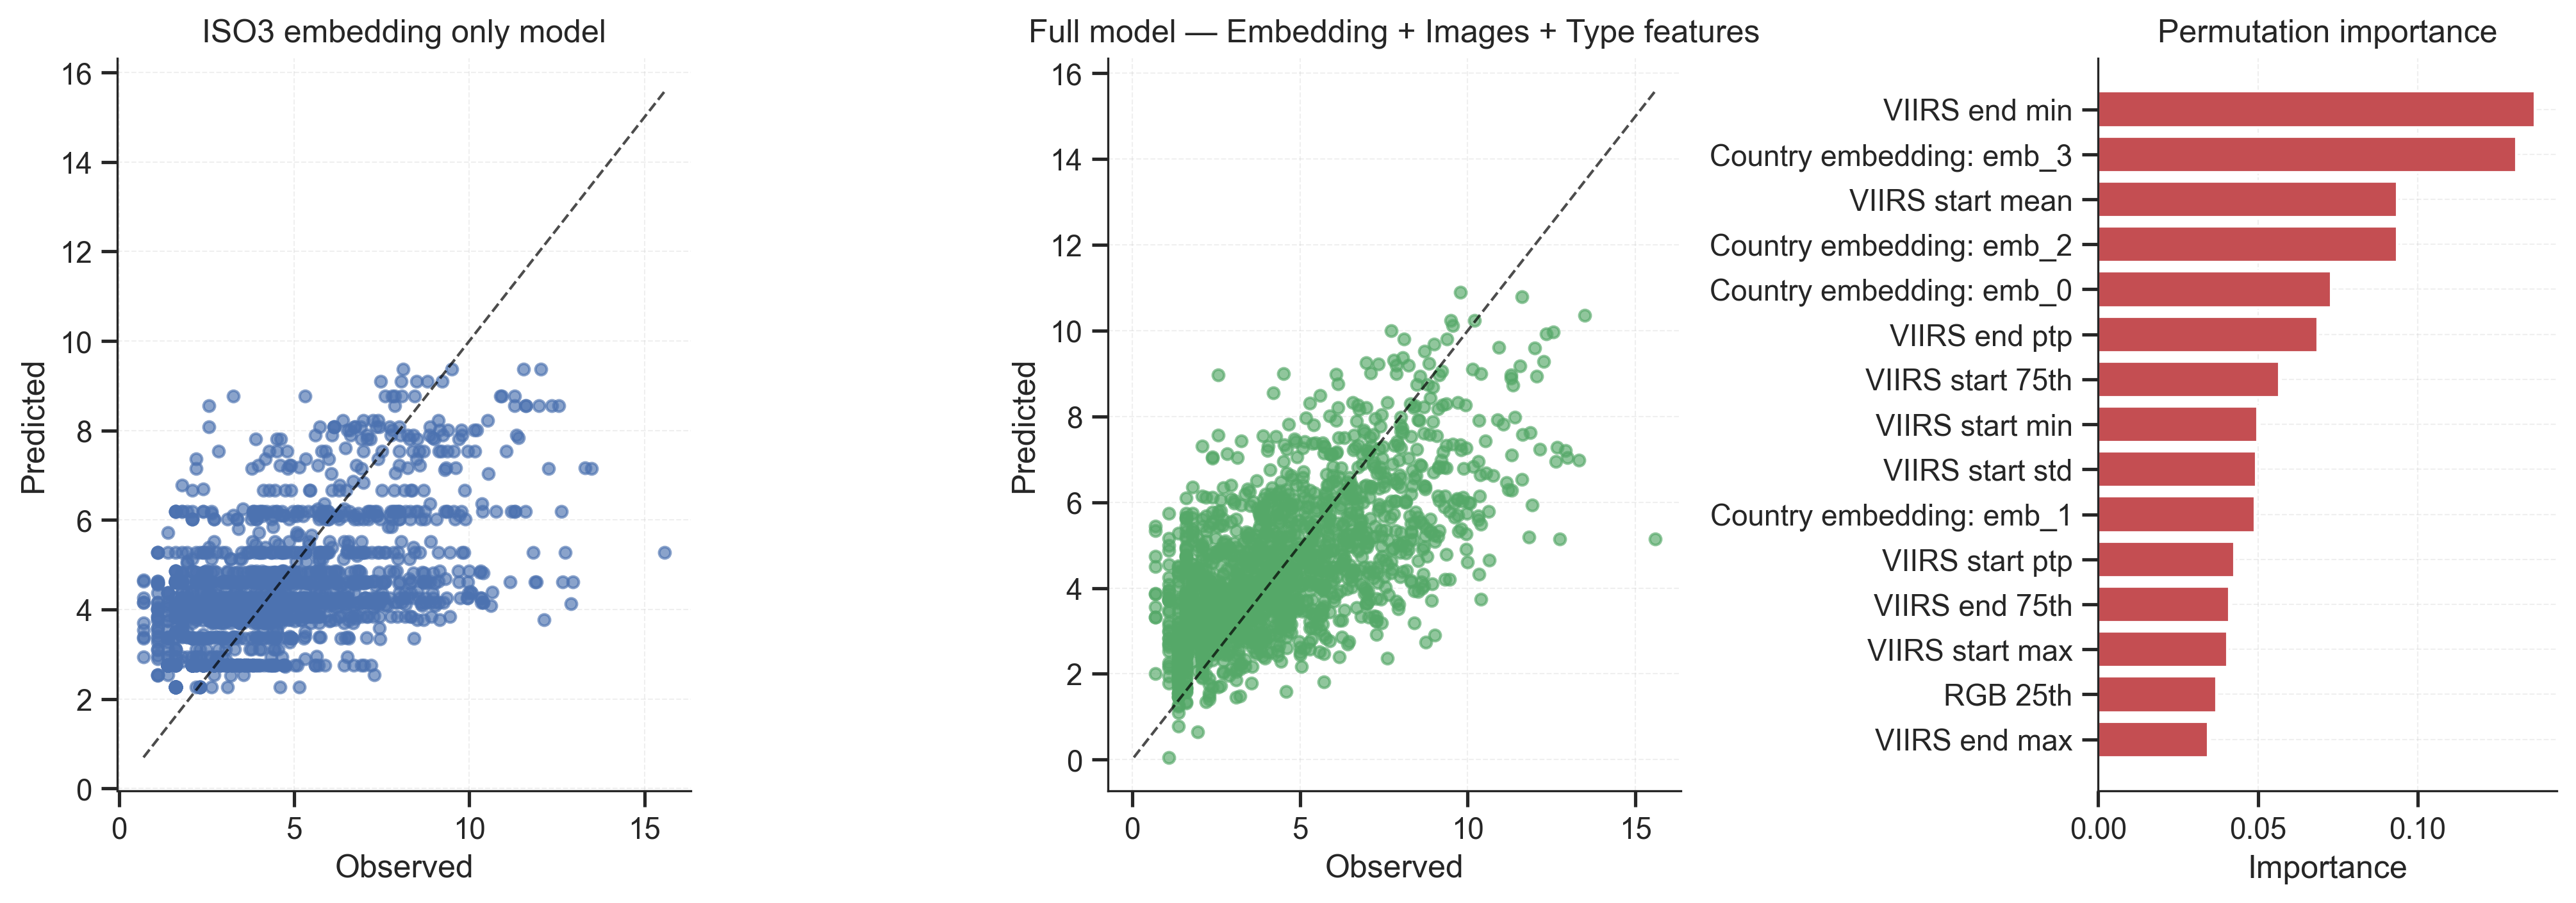

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor


# =========================================================
# CONFIG
# =========================================================
RANDOM_STATE = 42
TEST_SIZE = 0.1


# =========================================================
# ---------------- DATA + FEATURES ----------------
# =========================================================
def extract_image_statistics(image_array):
    if image_array is None or len(image_array) == 0:
        return np.zeros(8)

    try:
        img = np.array(image_array)
        if img.size == 0:
            return np.zeros(8)

        flat = img.flatten()
        return np.array([
            np.mean(flat),
            np.std(flat),
            np.min(flat),
            np.max(flat),
            np.percentile(flat, 25),
            np.percentile(flat, 50),
            np.percentile(flat, 75),
            np.ptp(flat)
        ])
    except:
        return np.zeros(8)


def build_image_features(df):
    def build(col, prefix):
        stats = df[col].apply(extract_image_statistics)
        arr = np.array(stats.tolist())
        return pd.DataFrame(arr, columns=[f"{prefix}_{i}" for i in range(8)])

    return pd.concat([
        build("viirs_start", "vs"),
        build("viirs_end", "ve"),
        build("rgb", "rgb")
    ], axis=1)


def build_feature_matrices(df, iso3_embeddings):

    embedding_df = iso3_embeddings.reset_index().rename(
        columns={iso3_embeddings.index.name or "index": "iso3"}
    )

    merged = df[["iso3", "figures", "viirs_start", "viirs_end", "rgb", "type"]].copy()
    merged = merged.merge(embedding_df, on="iso3", how="inner")

    embed_cols = [c for c in embedding_df.columns if c != "iso3"]
    X_embed = merged[embed_cols].to_numpy(np.float32)

    type_dummies = pd.get_dummies(merged["type"], prefix="type")
    merged = pd.concat([merged, type_dummies], axis=1)

    img_features = build_image_features(merged)
    merged = pd.concat([merged, img_features], axis=1)

    img_cols = list(img_features.columns)
    type_cols = list(type_dummies.columns)

    full_cols = embed_cols + type_cols + img_cols
    X_full = merged[full_cols].to_numpy(np.float32)

    y = merged["figures"].to_numpy(np.float32)

    return X_embed, X_full, y, embed_cols, full_cols


# =========================================================
# ---------------- MODEL TRAINING ----------------
# =========================================================
def train_xgb_model(X_train, y_train_log, X_val, y_val_log):

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=100
    )

    model.fit(
        X_train,
        y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False
    )

    return model


def predict(model, X):
    return model.predict(X)


# =========================================================
# ---------------- EVALUATION ----------------
# =========================================================
def evaluate(y_true_log, y_pred_log):
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE": np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    }


def human_readable_feature_names(feature_names):
    stat_map = {
        0: "mean",
        1: "std",
        2: "min",
        3: "max",
        4: "25th",
        5: "50th",
        6: "75th",
        7: "ptp",
    }

    def _readable(f):
        if isinstance(f, int):
            return f"Embedding_{f}"
        if f.startswith("type_"):
            return f"Type: {f[len('type_'):]}"

        # image feature prefixes used in build_image_features
        for prefix, label in [("vs", "VIIRS start"), ("ve", "VIIRS end"), ("rgb", "RGB")]:
            if f.startswith(prefix + "_"):
                try:
                    idx = int(f.split("_")[1])
                    return f"{label} {stat_map.get(idx, idx)}"
                except Exception:
                    return f"{label} {f.split('_',1)[1]}"

        # fallback: assume embedding or generic feature
        return f"Country embedding: {f}"

    return [ _readable(f) for f in feature_names ]


def permutation_importance_df(model, X_test, y_test_log, feature_names):
    result = permutation_importance(
        model,
        X_test,
        y_test_log,
        n_repeats=15,
        random_state=RANDOM_STATE,
        scoring="r2",
    )

    df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    })

    # add human readable labels for plotting
    df["display_name"] = human_readable_feature_names(df["feature"].tolist())

    return df.sort_values("importance_mean", ascending=False)


# =========================================================
# ---------------- PIPELINE ----------------
# =========================================================
def train_models(X_embed, X_full, y):

    y_log = np.log1p(y)

    Xe_train, Xe_test, y_train, y_test = train_test_split(
        X_embed, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    Xf_train, Xf_test, _, _ = train_test_split(
        X_full, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # ---- Embedding model
    embed_model = train_xgb_model(Xe_train, y_train, Xe_test, y_test)
    y_pred_embed = predict(embed_model, Xe_test)

    # ---- Full model
    full_model = train_xgb_model(Xf_train, y_train, Xf_test, y_test)
    y_pred_full = predict(full_model, Xf_test)

    metrics_embed = evaluate(y_test, y_pred_embed)
    metrics_full = evaluate(y_test, y_pred_full)

    return {
        "embed_model": embed_model,
        "full_model": full_model,
        "X_test_embed": Xe_test,
        "X_test_full": Xf_test,
        "y_test": y_test,
        "y_pred_embed": y_pred_embed,
        "y_pred_full": y_pred_full,
        "metrics_embed": metrics_embed,
        "metrics_full": metrics_full
    }


# =========================================================
# ---------------- PLOTTING (NATURE STYLE) ----------------
# =========================================================
def plot_results(results, perm_importance, top_n=15):

    y_true = results["y_test"]
    y_embed = results["y_pred_embed"]
    y_full = results["y_pred_full"]

    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "axes.linewidth": 0.8
    })

    fig = plt.figure(figsize=(13.5, 4.8), dpi=300)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 0.8], figure=fig)

    def style(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
        ax.set_axisbelow(True)

    # ---------------- Embedding ----------------
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.scatter(y_true, y_embed, s=18, alpha=0.65, color="#4C72B0")

    lims = [min(y_true.min(), y_embed.min()),
            max(y_true.max(), y_embed.max())]
    ax0.plot(lims, lims, "--", color="black", linewidth=1, alpha=0.7)

    ax0.set_title("ISO3 embedding only model")
    ax0.set_xlabel("Observed")
    ax0.set_ylabel("Predicted")
    style(ax0)

    # ---------------- Full model ----------------
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.scatter(y_true, y_full, s=18, alpha=0.65, color="#55A868")

    lims = [min(y_true.min(), y_full.min()),
            max(y_true.max(), y_full.max())]
    ax1.plot(lims, lims, "--", color="black", linewidth=1, alpha=0.7)

    ax1.set_title("Full model — Embedding + Images + Type features")
    ax1.set_xlabel("Observed")
    ax1.set_ylabel("Predicted")
    style(ax1)

    # ---------------- Importance ----------------
    ax2 = fig.add_subplot(gs[0, 2])

    top = perm_importance.head(top_n).iloc[::-1]

    # use human readable display names when available
    label_col = "display_name" if "display_name" in perm_importance.columns else "feature"
    ax2.barh(top[label_col], top["importance_mean"], color="#C44E52")

    ax2.set_title("Permutation importance")
    ax2.set_xlabel("Importance")
    style(ax2)

    plt.tight_layout()
    plt.show()


# =========================================================
# ---------------- RUN PIPELINE ----------------
# =========================================================
def run_pipeline(df, iso3_embeddings):

    X_embed, X_full, y, embed_cols, full_cols = build_feature_matrices(
        df, iso3_embeddings
    )

    results = train_models(X_embed, X_full, y)

    print("\n=== EMBEDDING MODEL ===")
    print(results["metrics_embed"])

    print("\n=== FULL MODEL ===")
    print(results["metrics_full"])

    perm_importance = permutation_importance_df(
        results["full_model"],
        results["X_test_full"],
        results["y_test"],
        full_cols
    )

    print("\n=== TOP FEATURES ===")
    print(perm_importance.head(20))

    plot_results(results, perm_importance)

    return results, perm_importance


# =========================================================
# RUN
# =========================================================
results, perm_importance = run_pipeline(df, iso3_embeddings)

# NN

- Architecture

In [20]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


class MultiBranchCNN(nn.Module):
    """
    Multi-branch CNN for regression over:
      - RGB satellite image  (ResNet-50 backbone)
      - VIIRS nightlight start/end  (lightweight CNN, separate branches)
      - Country-level scalar features  (small MLP)

    Branch output dims are proportional to information content:
      RGB → 128  |  VIIRS → 64 each  |  Country → 16  →  fused: 272
    """

    # Branch output dims — kept as class-level constants for clarity
    _RGB_DIM     = 128
    _VIIRS_DIM   = 64
    _COUNTRY_DIM = 16

    def __init__(self, country_features: int = 4, output_dim: int = 1, dropout: float = 0.3):
        super().__init__()
        self.output_dim = output_dim

        fuse_dim = self._RGB_DIM + self._VIIRS_DIM * 2 + self._COUNTRY_DIM  # 272

        # --- RGB backbone (ResNet-50, fully unfrozen) ---
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.rgb_backbone = backbone

        # Compress 2048 → 128 (smooth, ×4 steps)
        self.rgb_proj = self._mlp_block(2048, [512, self._RGB_DIM], dropout=dropout)

        # --- VIIRS branches (separate so start/end roles are distinct) ---
        self.viirs_start = self._viirs_branch()
        self.viirs_end   = self._viirs_branch()

        # --- Country projection (4 scalars → 16, no upscale bloat) ---
        self.country_proj = self._mlp_block(country_features, [self._COUNTRY_DIM], dropout=0.0)

        # --- Fusion MLP ---
        self.mlp = nn.Sequential(
            *self._mlp_block(fuse_dim, [128, 64], dropout=dropout).children(),
            nn.Linear(64, output_dim),
        )

        self._init_weights()

    # ------------------------------------------------------------------
    # Builders
    # ------------------------------------------------------------------

    @staticmethod
    def _mlp_block(in_dim: int, hidden_dims: list[int], dropout: float = 0.3) -> nn.Sequential:
        """Linear → BN → ReLU (→ Dropout) stack. No dropout on last layer."""
        layers = []
        for i, out_dim in enumerate(hidden_dims):
            layers += [nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU()]
            if dropout > 0 and i < len(hidden_dims) - 1:
                layers.append(nn.Dropout(dropout))
            in_dim = out_dim
        return nn.Sequential(*layers)

    @classmethod
    def _viirs_branch(cls) -> nn.Sequential:
        """Small CNN for single-channel nightlight tiles → (VIIRS_DIM,)."""
        def conv_bn_relu(in_c, out_c):
            return [nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()]

        return nn.Sequential(
            *conv_bn_relu(1, 32),
            *conv_bn_relu(32, 32),
            nn.MaxPool2d(2),
            *conv_bn_relu(32, cls._VIIRS_DIM),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )

    def _init_weights(self):
        """Kaiming Normal for all custom Linear / Conv2d layers."""
        custom = [self.rgb_proj, self.viirs_start, self.viirs_end,
                  self.country_proj, self.mlp]
        for block in custom:
            for m in block.modules():
                if isinstance(m, (nn.Linear, nn.Conv2d)):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    # ------------------------------------------------------------------
    # Forward
    # ------------------------------------------------------------------

    def forward(
        self,
        rgb_img: torch.Tensor,           # (B, 3, H, W)
        viirs_start: torch.Tensor,       # (B, 1, H', W')
        viirs_end: torch.Tensor,         # (B, 1, H', W')
        country_embedding: torch.Tensor, # (B, country_features)
    ) -> torch.Tensor:
        rgb     = self.rgb_proj(self.rgb_backbone(rgb_img))   # (B, 128)
        v_start = self.viirs_start(viirs_start)               # (B,  64)
        v_end   = self.viirs_end(viirs_end)                   # (B,  64)
        country = self.country_proj(country_embedding)         # (B,  16)

        fused  = torch.cat([rgb, v_start, v_end, country], dim=1)  # (B, 272)
        output = self.mlp(fused)                                    # (B, output_dim)
        return output

- Hyperparameters
    - last I used is 1e-5, 64 batch
    

In [21]:
batch_size = 64  # we reached .7 training on this .15 for test (64, and 1e-5 works too)
learning_rate = 1e-3 # e-5 was fine , batch size 32 (.37 train, .09 test)
weight_decay = 1e-4 # -5 is fine. 
num_epochs = 40

- Transform

In [22]:
class JointTransform:
    def __init__(self, target_size=(224, 224), train: bool = True,
                 viirs_mean: float = 0.42, viirs_std: float = 0.81):
        self.train = train
        self.viirs_mean = viirs_mean
        self.viirs_std  = viirs_std

        self.resize_rgb = transforms.Resize(
            target_size,
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=True,
        )
        self.color_jitter = transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        )
        self.normalize_rgb = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )

    def _normalize_viirs(self, t: torch.Tensor) -> torch.Tensor:
        t = torch.log1p(t.float())
        return (t - self.viirs_mean) / self.viirs_std

    def __call__(self, rgb, viirs_start, viirs_end):
        # rgb is PIL at this point; viirs_* are already tensors
        rgb = self.resize_rgb(rgb)

        if self.train:
            rgb = self.color_jitter(rgb)
            if random.random() > 0.5:
                rgb, viirs_start, viirs_end = map(TF.hflip, [rgb, viirs_start, viirs_end])
            if random.random() > 0.5:
                rgb, viirs_start, viirs_end = map(TF.vflip, [rgb, viirs_start, viirs_end])

        rgb = self.normalize_rgb(rgb)
        viirs_start = self._normalize_viirs(viirs_start)
        viirs_end   = self._normalize_viirs(viirs_end)

        return rgb, viirs_start, viirs_end

- Dataset and DataLoader

In [23]:
class IDPDataset(Dataset):
    def __init__(self, df, joint_transform=None, target_col="figures", target_transform=None):
        self.joint_transform = joint_transform
        self.target_transform = target_transform

        # Pre-extract to numpy once — avoids repeated iloc overhead
        self.viirs_start  = df["viirs_start"].to_numpy()
        self.viirs_end    = df["viirs_end"].to_numpy()
        self.rgb          = df["rgb"].to_numpy()
        self.targets      = torch.tensor(df[target_col].values,    dtype=torch.float32)
        self.iso3_encoded = torch.tensor(
            np.stack(df["iso3_encoded"].values), dtype=torch.float32
        )  # (N, 3)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        # VIIRS: stored as (H, W) → (1, H, W)
        viirs_start = torch.as_tensor(self.viirs_start[idx]).float().unsqueeze(0)
        viirs_end   = torch.as_tensor(self.viirs_end[idx]).float().unsqueeze(0)

        # RGB: stored as (H, W, C) uint8 → (C, H, W) float in [0, 1]
        rgb = torch.as_tensor(self.rgb[idx]).float() / 255.0
        rgb = rgb.permute(2, 0, 1)  # (H, W, 3) → (3, H, W)

        if self.joint_transform:
            rgb, viirs_start, viirs_end = self.joint_transform(rgb, viirs_start, viirs_end)

        target = self.targets[idx]
        if self.target_transform:
            target = self.target_transform(target)

        return rgb, viirs_start, viirs_end, target.unsqueeze(0), self.iso3_encoded[idx]

In [ ]:
# ── 1. Build iso3 → embedding lookup ─────────────────────────────────────────
embedding_key = None
for candidate in ("iso3", "iso3_mapped"):
    if candidate in iso3_embeddings.columns:
        embedding_key = candidate
        break

if embedding_key is None and getattr(iso3_embeddings.index, "name", None) in ("iso3", "iso3_mapped"):
    emb_df = iso3_embeddings.copy()
else:
    emb_df = iso3_embeddings.copy().reset_index()
    index_name = iso3_embeddings.index.name or "index"
    if index_name not in emb_df.columns:
        emb_df = emb_df.rename(columns={index_name: "iso3"})
    if embedding_key is None and "iso3" not in emb_df.columns and "iso3_mapped" in emb_df.columns:
        emb_df = emb_df.rename(columns={"iso3_mapped": "iso3"})
    if "iso3" not in emb_df.columns and "iso3_mapped" not in emb_df.columns:
        raise KeyError("Could not find an ISO3 identifier column in iso3_embeddings")

if embedding_key is None:
    emb_df = emb_df.rename_axis("iso3").reset_index() if getattr(emb_df.index, "name", None) in ("iso3", "iso3_mapped") else emb_df
    if "iso3" not in emb_df.columns and "iso3_mapped" in emb_df.columns:
        emb_df = emb_df.rename(columns={"iso3_mapped": "iso3"})
else:
    emb_df = emb_df.rename(columns={embedding_key: "iso3"})

emb_df = emb_df.set_index("iso3").select_dtypes(include=[np.number])
N_COUNTRY_FEATURES = emb_df.shape[1]


def _get_embedding(code: str) -> np.ndarray:
    try:
        row = emb_df.loc[code]
        if isinstance(row, pd.DataFrame):   # handles duplicate iso3 rows
            row = row.iloc[0]
        return np.asarray(row, dtype=np.float32).ravel()
    except KeyError:
        return np.zeros(N_COUNTRY_FEATURES, dtype=np.float32)


df["iso3_encoded"] = df["iso3"].apply(_get_embedding)

# ── 2. Train / val / test split ───────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ── 3. Target normalization (log1p + z-score using training data only) ─────────
target_log_train = np.log1p(train_df["figures"].astype(np.float32).to_numpy())
TARGET_LOG_MEAN = float(target_log_train.mean())
TARGET_LOG_STD = float(target_log_train.std()) + 1e-6


def _normalize_target(target):
    target_tensor = torch.as_tensor(target, dtype=torch.float32)
    return (torch.log1p(target_tensor) - TARGET_LOG_MEAN) / TARGET_LOG_STD


def _denormalize_target(target):
    target_array = np.asarray(target, dtype=np.float32)
    return np.expm1(target_array * TARGET_LOG_STD + TARGET_LOG_MEAN)


# ── 4. VIIRS normalisation stats (training data only — no leakage) ────────────
viirs_log = np.concatenate([
    np.log1p(np.stack(train_df["viirs_start"].values).ravel()),
    np.log1p(np.stack(train_df["viirs_end"].values).ravel()),
])
VIIRS_MEAN = float(viirs_log.mean())
VIIRS_STD  = float(viirs_log.std()) + 1e-6

# ── 5. Transforms ─────────────────────────────────────────────────────────────
train_transform = JointTransform(
    target_size=(224, 224),
    train=True,
    viirs_mean=VIIRS_MEAN,
    viirs_std=VIIRS_STD,
)
eval_transform = JointTransform(
    target_size=(224, 224),
    train=False,
    viirs_mean=VIIRS_MEAN,
    viirs_std=VIIRS_STD,
)

# ── 6. Datasets ───────────────────────────────────────────────────────────────
train_dataset = IDPDataset(
    df=train_df,
    joint_transform=train_transform,
    target_transform=_normalize_target,
)
val_dataset = IDPDataset(
    df=val_df,
    joint_transform=eval_transform,
    target_transform=_normalize_target,
)
test_dataset = IDPDataset(
    df=test_df,
    joint_transform=eval_transform,
    target_transform=_normalize_target,
)

# ── 7. Model ──────────────────────────────────────────────────────────────────
model = MultiBranchCNN(country_features=N_COUNTRY_FEATURES, output_dim=1)

In [25]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [26]:
model = MultiBranchCNN(output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# scheduler = ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=5, verbose=True
# )

In [27]:
summary(
    model,
    input_size=(
        ( batch_size, 3, 224, 224),
        ( batch_size, 1, 20, 20),
        ( batch_size, 1, 20, 20),
        ( batch_size, 4),
    ),
    device=device.type,
)

Layer (type:depth-idx)                        Output Shape              Param #
MultiBranchCNN                                [64, 1]                   --
├─ResNet: 1-1                                 [64, 2048]                --
│    └─Conv2d: 2-1                            [64, 64, 112, 112]        9,408
│    └─BatchNorm2d: 2-2                       [64, 64, 112, 112]        128
│    └─ReLU: 2-3                              [64, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [64, 64, 56, 56]          --
│    └─Sequential: 2-5                        [64, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [64, 256, 56, 56]         75,008
│    │    └─Bottleneck: 3-2                   [64, 256, 56, 56]         70,400
│    │    └─Bottleneck: 3-3                   [64, 256, 56, 56]         70,400
│    └─Sequential: 2-6                        [64, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [64, 512, 28, 28]         379,392

In [28]:
# show one batch of data to verify everything is working
for rgb, viirs_start, viirs_end, targets, iso3_emb in train_loader:
    print("RGB batch shape:", rgb.shape)  # (B, 3, H, W)
    print("VIIRS start batch shape:", viirs_start.shape)  # (B, 1, H', W')
    print("VIIRS end batch shape:", viirs_end.shape)  # (B, 1, H', W')
    print("Country embedding batch shape:", iso3_emb.shape)  # (B, country_features)
    print("Targets batch shape:", targets.shape)  # (B,)
    break

RGB batch shape: torch.Size([64, 3, 224, 224])
VIIRS start batch shape: torch.Size([64, 1, 20, 20])
VIIRS end batch shape: torch.Size([64, 1, 20, 20])
Country embedding batch shape: torch.Size([64, 4])
Targets batch shape: torch.Size([64, 1])


# Training

In [29]:
train_size = len(train_loader.dataset)
val_size = len(val_loader.dataset)
test_size = len(test_loader.dataset)
print(f"Training samples: {train_size}, Validation samples: {val_size}, Test samples: {test_size}")

Training samples: 11827, Validation samples: 2534, Test samples: 2535


In [ ]:
best_loss = float("inf")
patience = 10
patience_counter = 0
train_losses = []
val_losses = []

print(f"Training on {train_size} examples, validating on {val_size} examples")

for epoch in range(num_epochs):

    for param_group in optimizer.param_groups:
        print(f"Current learning rate: {param_group['lr']}")
        
    # Training phase
    model.train()
    epoch_train_loss = 0.0

    for rgb, viirs_start, viirs_end, targets, iso3_emb in train_loader:
        # Move data to device
        rgb = rgb.to(device)
        viirs_start = viirs_start.to(device)
        viirs_end = viirs_end.to(device)
        targets = targets.to(device)
        iso3_emb = iso3_emb.to(device)

        # Forward pass
        outputs = model(rgb, viirs_start, viirs_end, iso3_emb)
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for rgb, viirs_start, viirs_end, targets, iso3_emb in val_loader:
            rgb = rgb.to(device)
            viirs_start = viirs_start.to(device)
            viirs_end = viirs_end.to(device)
            targets = targets.to(device)
            iso3_emb = iso3_emb.to(device)

            outputs = model(rgb, viirs_start, viirs_end, iso3_emb)
            val_loss = criterion(outputs, targets)
            epoch_val_loss += val_loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    # scheduler.step(epoch_val_loss)

    # Print epoch statistics
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}"
    )

    # Early stopping
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), folder_path + "checkpoints/best_model_gidd.pth")
        print(f" ✅ Saved with validation loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

Training on 11827 examples, validating on 2534 examples
Current learning rate: 0.001


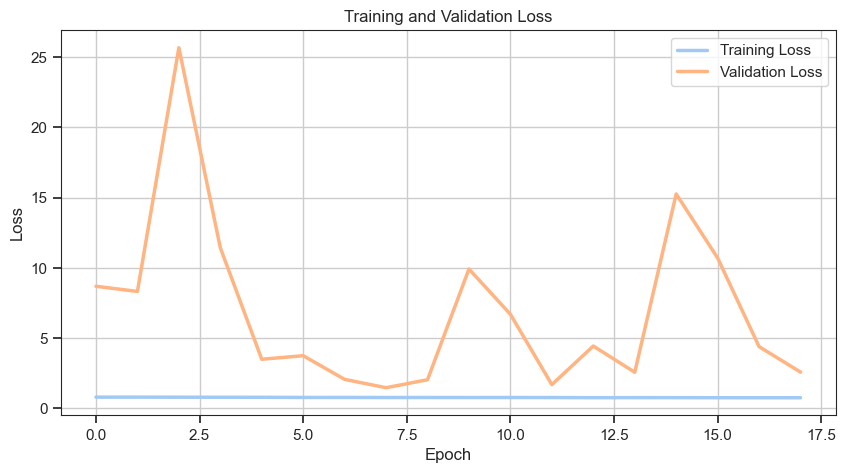

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# if using ReduceLROnPlateau, restore lr
if "scheduler" in locals():
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate  # Reset learning rate to initial value

# Load best model

- Inference using best model

In [ ]:
model.load_state_dict(torch.load(folder_path + "checkpoints/best_model_gidd.pth"))

<All keys matched successfully>

In [ ]:
def predict_batch(model, batch, device):
    model.eval()
    rgb, viirs_start, viirs_end, targets, iso3_emb = batch  # <-- capture targets

    rgb = rgb.to(device)
    viirs_start = viirs_start.to(device)
    viirs_end = viirs_end.to(device)
    iso3_emb = iso3_emb.to(device)
    targets = targets.to(device)

    with torch.no_grad():
        outputs = model(rgb, viirs_start, viirs_end, iso3_emb)

    return outputs.cpu().numpy(), targets.cpu().numpy()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_predictions_and_targets_log_space(model, dataloader, device):
    """Gets predictions and targets in log space (normalized)."""
    model.eval()
    predictions, targets = [], []

    with torch.no_grad():
        for batch in dataloader:
            batch_preds, batch_targets = predict_batch(model, batch, device)
            predictions.extend(batch_preds)
            targets.extend(batch_targets)

    # Return in log space (normalized) — do NOT denormalize
    predictions = np.array(predictions)
    targets = np.array(targets)
    return predictions, targets


# Compute R² in log space for all three datasets
print("=" * 60)
print("R² SCORES IN LOG SPACE (normalized)")
print("=" * 60)

pred_train_log, targets_train_log = get_predictions_and_targets_log_space(model, train_loader, device)
r2_train_log = r2_score(targets_train_log, pred_train_log)
print(f"Train R² (log space):      {r2_train_log:.6f}")

pred_val_log, targets_val_log = get_predictions_and_targets_log_space(model, val_loader, device)
r2_val_log = r2_score(targets_val_log, pred_val_log)
print(f"Validation R² (log space): {r2_val_log:.6f}")

pred_test_log, targets_test_log = get_predictions_and_targets_log_space(model, test_loader, device)
r2_test_log = r2_score(targets_test_log, pred_test_log)
print(f"Test R² (log space):       {r2_test_log:.6f}")

print("=" * 60)
print("ADDITIONAL METRICS (log space)")
print("=" * 60)
mae_test_log = mean_absolute_error(targets_test_log, pred_test_log)
rmse_test_log = np.sqrt(mean_squared_error(targets_test_log, pred_test_log))
print(f"Test MAE (log space):      {mae_test_log:.6f}")
print(f"Test RMSE (log space):     {rmse_test_log:.6f}")
print("=" * 60)

R² SCORES IN LOG SPACE (normalized)
Train R² (log space):      -0.497715
Validation R² (log space): -0.463323
Test R² (log space):       -0.517207
ADDITIONAL METRICS (log space)
Test MAE (log space):      1.042404
Test RMSE (log space):     1.205377


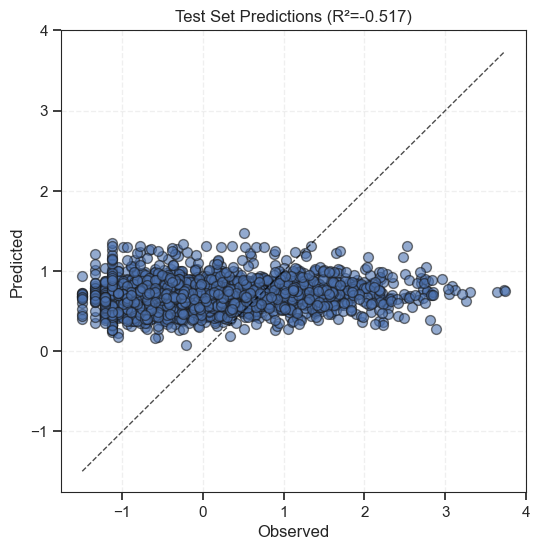

In [ ]:
# plot r2 scatter in log space
plt.figure(figsize=(6, 6))
plt.scatter(targets_test_log, pred_test_log, alpha=0.6, color="#4C72B0", edgecolor="k", s=50)
lims = [min(targets_test_log.min(), pred_test_log.min()), max(targets_test_log.max(), pred_test_log.max())]
plt.plot(lims, lims, "--", color="black", linewidth=1, alpha=0.7)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title(f"Test Set Predictions (R²={r2_test_log:.3f})")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()